In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cleaned_data.csv')

In [3]:
df.iloc[0].to_frame("sample")

,sample
Poster_Link,https://m.media-amazon.com/images/M/MV5BMDFkYT...
Series_Title,The Shawshank Redemption
Released_Year,1994
Certificate,A
Runtime,142
Genre,Drama
IMDB_Rating,9.3
Overview,Two imprisoned men bond over a number of years...
Meta_score,80.0
Director,Frank Darabont


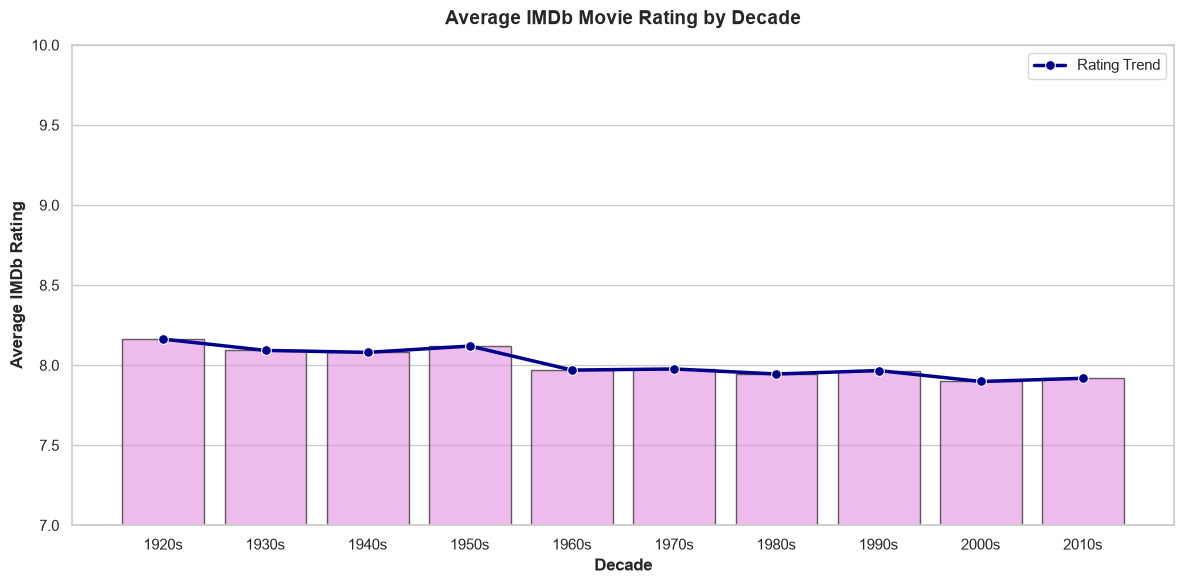

In [4]:
sns.set_theme(style="whitegrid", palette="muted")

# unnecessary rows dropped
df = df.dropna(subset=["Released_Year", "IMDB_Rating"]).copy()

# create decades
df["Decade"] = (df["Released_Year"] // 10) * 10

decade_stats = (
    df.groupby("Decade")["IMDB_Rating"]
      .agg(Mean_Rating="mean", Count="count")
      .reset_index()
      .sort_values("Decade")
)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=decade_stats,
    x="Decade",
    y="Mean_Rating",
    ax=ax,
    color="violet",
    alpha=0.6,
    edgecolor="black"
)

# add trendline
x = np.arange(len(decade_stats))

sns.lineplot(
    x=x,
    y=decade_stats["Mean_Rating"],
    ax=ax,
    color="darkblue",
    linewidth=2.5,
    marker="o",
    markersize=7,
    label="Rating Trend"
)


ax.set_xticks(x)
ax.set_xticklabels([f"{int(d)}s" for d in decade_stats["Decade"]])


ax.set_xlabel("Decade", fontsize=12, fontweight="bold")
ax.set_ylabel("Average IMDb Rating", fontsize=12, fontweight="bold")
ax.set_title(
    "Average IMDb Movie Rating by Decade",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# rating range
ax.set_ylim(7, 10)

ax.legend()
plt.tight_layout()
plt.show()

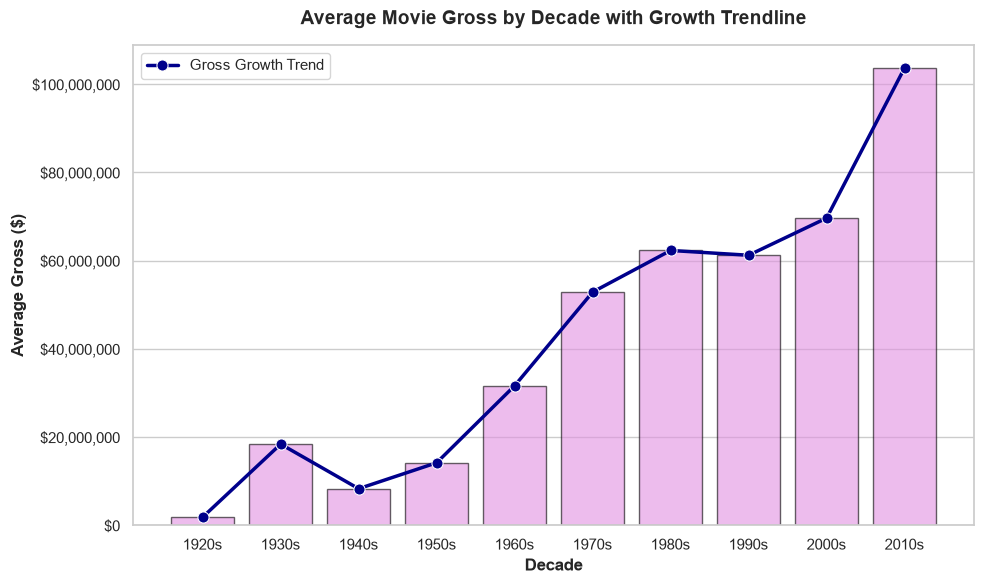

In [5]:
from matplotlib.ticker import FuncFormatter

# setting a theme
sns.set_theme(style="whitegrid", palette="muted")

# avg gross by each dec
decade_stats = (
    df.groupby("Decade")["Gross"]
    .agg(Mean_Gross="mean", Total_Gross="sum", Count="count")
    .reset_index()
    .sort_values("Decade")
)

# pct change between decades
decade_stats["Gross_Change_Pct"] = (
    decade_stats["Mean_Gross"].pct_change() * 100
)

# ploting
fig, ax1 = plt.subplots(figsize=(10, 6))

x_indexes = np.arange(len(decade_stats))


sns.barplot(
    x=x_indexes,
    y=decade_stats["Mean_Gross"],
    ax=ax1,
    color="violet",
    alpha=0.6,
    edgecolor="black",
)


ax1.set_ylabel("Average Gross ($)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Decade", fontsize=12, fontweight="bold")
ax1.set_title(
    "Average Movie Gross by Decade with Growth Trendline",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# adding trendline
sns.lineplot(
    x=x_indexes,
    y=decade_stats["Mean_Gross"],
    ax=ax1,
    color="darkblue",
    linewidth=2.5,
    marker="o",
    markersize=8,
    label="Gross Growth Trend",
)


ax1.set_xticks(x_indexes)
ax1.set_xticklabels([f"{int(d)}s" for d in decade_stats["Decade"]])

ax1.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [6]:
table = (
    df.groupby("Decade")
      .agg(
          Average_Gross=("Gross", "mean"),
          Highest_Gross=("Gross", "max")
      )
      .reset_index()
)

best_films = (
    df.loc[
        df.groupby("Decade")["Gross"].idxmax(),
        ["Decade", "Series_Title", "Gross", "IMDB_Rating",
         "Genre", "Director", "Star1", "Runtime"]
    ]
)

table = table.merge(best_films, on="Decade")

table = table.rename(columns={
    "Average_Gross": "Average Gross",
    "Series_Title": "Highest-Grossing Film",
    "Gross": "Film Gross",
    "IMDB_Rating": "IMDb Rating",
    "Star1": "Starring"
})

table = table[
    ["Decade", "Average Gross", "Highest-Grossing Film",
     "Film Gross", "IMDb Rating", "Genre", "Director",
     "Starring", "Runtime"]
]

table["Average Gross"] = table["Average Gross"].map(lambda x: f"${x:,.0f}")
table["Film Gross"] = table["Film Gross"].map(lambda x: f"${x:,.0f}")

table

,Decade,Average Gross,Highest-Grossing Film,Film Gross,IMDb Rating,Genre,Director,Starring,Runtime
0,1920,"$1,844,978",The Kid,"$5,450,000",8.3,"Comedy, Drama, Family",Charles Chaplin,Charles Chaplin,68
1,1930,"$18,403,476",Gone with the Wind,"$198,676,459",8.1,"Drama, History, Romance",Victor Fleming,George Cukor,238
2,1940,"$8,293,462",Fantasia,"$76,408,097",7.7,"Animation, Family, Fantasy",James Algar,Samuel Armstrong,125
3,1950,"$14,174,694",The Ten Commandments,"$93,740,000",7.9,"Adventure, Drama",Cecil B. DeMille,Charlton Heston,220
4,1960,"$31,634,777",The Sound of Music,"$163,214,286",8.0,"Biography, Drama, Family",Robert Wise,Julie Andrews,172
5,1970,"$52,879,527",Star Wars,"$322,740,140",8.6,"Action, Adventure, Fantasy",George Lucas,Mark Hamill,121
6,1980,"$62,314,866",E.T. the Extra-Terrestrial,"$435,110,554",7.8,"Family, Sci-Fi",Steven Spielberg,Henry Thomas,115
7,1990,"$61,229,999",Titanic,"$659,325,379",7.8,"Drama, Romance",James Cameron,Leonardo DiCaprio,194
8,2000,"$69,658,081",Avatar,"$760,507,625",7.8,"Action, Adventure, Fantasy",James Cameron,Sam Worthington,162
9,2010,"$103,720,361",Star Wars: Episode VII - The Force Awakens,"$936,662,225",7.9,"Action, Adventure, Sci-Fi",J.J. Abrams,Daisy Ridley,138


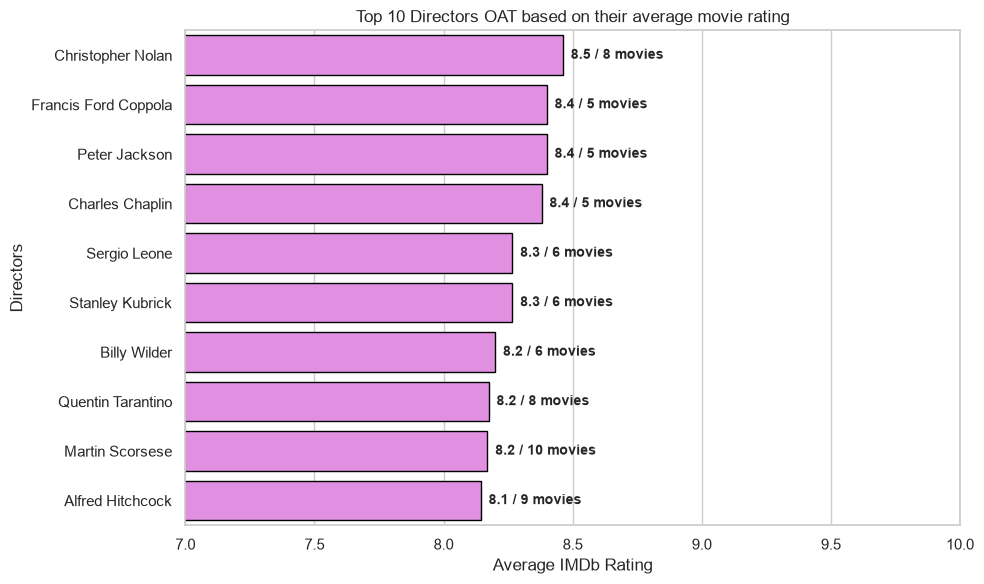

In [7]:
plt.figure(figsize=(10, 6))

director_stats = (
    df.groupby("Director")
      .agg(
          Average_Rating=("IMDB_Rating", "mean"),
          Movie_Count=("IMDB_Rating", "count")
      )
      .query("Movie_Count >= 5")
      .sort_values("Average_Rating", ascending=False)
      .head(10)
      .reset_index()
)

ax = sns.barplot(
    data=director_stats,
    x="Average_Rating",
    y="Director",
    color="violet",
    edgecolor="black"
)

for i, row in director_stats.iterrows():
    ax.text(
        row["Average_Rating"] + 0.03,
        i,
        f'{row["Average_Rating"]:.1f} / {row["Movie_Count"]} movies',
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xlabel("Average IMDb Rating")
ax.set_ylabel("Directors")
ax.set_title("Top 10 Directors OAT based on their average movie rating")
ax.set_xlim(7, 10)

plt.tight_layout()
plt.show()

In [8]:
top_10_gross = (
    df.assign(
        Released_Year=pd.to_numeric(df["Released_Year"], errors="coerce"),    )
    .dropna(subset=["Gross"])
    .sort_values("Gross", ascending=False)
    .head(10)
    [["Series_Title", "Released_Year", "Runtime", "Gross", "Certificate"]]
    .rename(columns={
        "Series_Title": "Title",
        "Released_Year": "Release_Year",
        "Runtime": "Runtime_Min",
        "Gross": "Gross_USD",
        "Certificate": "Certificate"
    })
    .reset_index(drop=True)
)

top_10_gross.index += 1
top_10_gross["Release_Year"] = top_10_gross["Release_Year"].astype(int)
top_10_gross["Gross_USD"] = top_10_gross["Gross_USD"].map("${:,.0f}".format)

top_10_gross

,Title,Release_Year,Runtime_Min,Gross_USD,Certificate
1,Star Wars: Episode VII - The Force Awakens,2015,138,"$936,662,225",U
2,Avengers: Endgame,2019,181,"$858,373,000",UA
3,Avatar,2009,162,"$760,507,625",UA
4,Avengers: Infinity War,2018,149,"$678,815,482",UA
5,Titanic,1997,194,"$659,325,379",UA
6,The Avengers,2012,143,"$623,279,547",UA
7,Incredibles 2,2018,118,"$608,581,744",UA
8,The Dark Knight,2008,152,"$534,858,444",UA
9,Rogue One,2016,133,"$532,177,324",UA
10,The Dark Knight Rises,2012,164,"$448,139,099",UA
